# Overview

Testing out BLOSUM based encoding methods and combining a 3 stage archectecture to make predictions on class 1 MHC data. 


In [67]:
import torch
from torch import nn
from torch.utils.data import Subset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler  
import numpy as np
from Bio.Align import substitution_matrices
import pandas as pd
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import esm
import esm.pretrained
 

#imports

In [68]:
overall_df = pd.read_csv("/Users/shubhaychoubey/Documents/GitHub/Peptide/Data/ML_Ready/mhc_class_II.csv")

# columns that directly encode the label or act as proxies for it
LEAKY_COLS = [
    "Disease",             # corr=0.9954 - essentially the label in text form
    "strat_key",           # corr=0.9518 - encodes is_cancer as the first character ("0_xx" / "1_xx")
    "found_in_healthy",    # corr=0.9710 - derived from is_cancer, near-perfect inverse flag
    "ID",                  # corr=0.7299 - sequential IDs differ between cancer and healthy sources
    "Tissue",              # corr=0.4391 - tissue-disease collinearity (BRAIN=glio, SKIN=melanoma)
    "hla_population_freq", # corr=0.3750 - allele freq differs between cancer/healthy cohorts
    "Best HLA Allele",     # corr=0.2431 - different allele distributions per cohort
    "Uniprot IDs",         # corr=0.2044 - cancer proteins vs normal proteome proteins
    "source",              # tags which database the row came from (iedb=cancer, pci=healthy)
    "hla_source",          # metadata tied to source
    "hla_known",           # metadata
    "feature_error",       # metadata
    "Affinity % Rank",     # not a peptide sequence feature
    "affinity_bin",        # derived from affinity rank
    "is_strong_binder",    # derived from affinity rank
    "is_weak_binder",      # derived from affinity rank
    "is_non_binder",       # derived from affinity rank
    "ms_confirmed",        # constant (all 1s), no signal
    "MHC Class",           # constant (all II), no signal
    "Peptide Modifications", # mostly empty
    "length_class",        # string version of length, redundant with length column
]

overall_df = overall_df.drop(columns=LEAKY_COLS, errors='ignore')

# drop columns that are more than 50% empty
limit = len(overall_df) * 0.5
overall_df = overall_df.dropna(thresh=limit, axis=1)

overall_df = overall_df.dropna(subset=['is_cancer', 'Peptide Sequence'])

print(f"Rows: {len(overall_df)}  Columns: {len(overall_df.columns)}")
print("Remaining columns:", overall_df.columns.tolist())

Rows: 10975  Columns: 53
Remaining columns: ['Peptide Sequence', 'length', 'molecular_weight', 'charge_pH_7', 'hydrophobicity_GRAVY', 'isoelectric_point', 'aromaticity', 'instability_index', 'helix_fraction', 'sheet_fraction', 'turn_fraction', 'aliphatic_index', 'boman_index', 'n_term_residue', 'c_term_residue', 'anchor_pos_2', 'anchor_pos_C', 'anchor_p2_hydro', 'anchor_pC_hydro', 'blosum62_p2', 'blosum62_pC', 'tcr_contact_hydro_mean', 'tcr_aromatic_count', 'tcr_hydrophobic_count', 'has_tryptophan', 'tryptophan_count', 'tryptophan_at_tcr_pos', 'hydrophobic_residue_count', 'hydrophobic_fraction', 'aromatic_residue_count', 'has_aromatic_central', 'is_9mer', 'aa_pct_A', 'aa_pct_C', 'aa_pct_D', 'aa_pct_E', 'aa_pct_F', 'aa_pct_G', 'aa_pct_H', 'aa_pct_I', 'aa_pct_K', 'aa_pct_L', 'aa_pct_M', 'aa_pct_N', 'aa_pct_P', 'aa_pct_Q', 'aa_pct_R', 'aa_pct_S', 'aa_pct_T', 'aa_pct_V', 'aa_pct_W', 'aa_pct_Y', 'is_cancer']


In [69]:
# PyTorch versions!!!

# 1. Position encoding with BLOSUM62 and anchor position weightage. 

ALPHABET = "ARNDCQEGHILKMFPSTWYV"
_matrix = substitution_matrices.load("BLOSUM62")
 
def encode_peptide_to_blosum(sequence: str) -> torch.Tensor:
    vectors = [] # Defines a list to hold the BLOSUM vectors for each amino acid in the sequence
    for aa in sequence.upper():  #loops thorugh the amino acids in the input sequence, converting them to uppercase to match the BLOSUM matrix keys
        vec = [] 
        for ref_aa in ALPHABET: #loops through the standard amino acids defined in the ALPHABET string, calculating the BLOSUM score for each pair of (aa, ref_aa)  
            try:
                score = _matrix[(aa, ref_aa)]
            except KeyError:
                score = _matrix.get((ref_aa, aa), -4)
            vec.append(float(score))
        vectors.append(vec)
    return torch.tensor(vectors, dtype=torch.float32)  # shape: (L, 20)



def build_anchor_bias(seq_len: int,
                      mhc_anchor_strength: float = -2.0,
                      tcr_anchor_strength: float = +2.0) -> torch.Tensor:
    
    bias = torch.zeros(seq_len, seq_len)

    # MHC-facing anchor columns (all rows attend less to these positions)
    anchor_cols = {1, seq_len - 1}           # position 2 and C-term (0-indexed)
    for col in anchor_cols:
        if col < seq_len:
            bias[:, col] += mhc_anchor_strength
 
    # TCR-facing columns (all rows attend more to these positions)
    tcr_start = 2
    tcr_end   = min(seq_len - 2, 7)         # positions 3–7 (0-indexed: 2–6)
    for col in range(tcr_start, tcr_end + 1):
        bias[:, col] += tcr_anchor_strength
 
    return bias  # (seq_len, seq_len)
 

# Testing

peptide = overall_df['Peptide Sequence'].iloc[1000]
blosum_encoded = encode_peptide_to_blosum(peptide)
anchor_bias = build_anchor_bias(len(peptide))

print(f"Peptide: {peptide}"
      f"\nBLOSUM Encoded Shape: {blosum_encoded.shape}"
      f"\nAnchor Bias Shape: {anchor_bias.shape}")

for i in range(min(5, blosum_encoded.shape[0])):
    print(f"Position {i+1} BLOSUM Vector: {blosum_encoded[i].tolist()}")    

for x in range(min(5, anchor_bias.shape[0])):
    print(f"Position {x+1} Anchor Bias: {anchor_bias[x].tolist()}")
    

Peptide: EDKQILSADDKTVRLWDHA
BLOSUM Encoded Shape: torch.Size([19, 20])
Anchor Bias Shape: torch.Size([19, 19])
Position 1 BLOSUM Vector: [-1.0, 0.0, 0.0, 2.0, -4.0, 2.0, 5.0, -2.0, 0.0, -3.0, -3.0, 1.0, -2.0, -3.0, -1.0, 0.0, -1.0, -3.0, -2.0, -2.0]
Position 2 BLOSUM Vector: [-2.0, -2.0, 1.0, 6.0, -3.0, 0.0, 2.0, -1.0, -1.0, -3.0, -4.0, -1.0, -3.0, -3.0, -1.0, 0.0, -1.0, -4.0, -3.0, -3.0]
Position 3 BLOSUM Vector: [-1.0, 2.0, 0.0, -1.0, -3.0, 1.0, 1.0, -2.0, -1.0, -3.0, -2.0, 5.0, -1.0, -3.0, -1.0, 0.0, -1.0, -3.0, -2.0, -2.0]
Position 4 BLOSUM Vector: [-1.0, 1.0, 0.0, 0.0, -3.0, 5.0, 2.0, -2.0, 0.0, -3.0, -2.0, 1.0, 0.0, -3.0, -1.0, 0.0, -1.0, -2.0, -1.0, -2.0]
Position 5 BLOSUM Vector: [-1.0, -3.0, -3.0, -3.0, -1.0, -3.0, -3.0, -4.0, -3.0, 4.0, 2.0, -3.0, 1.0, 0.0, -3.0, -2.0, -1.0, -3.0, -1.0, 3.0]
Position 1 Anchor Bias: [0.0, -2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.0]
Position 2 Anchor Bias: [0.0, -2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0

In [70]:
class AnchorBiasedMHA(nn.Module): # set up the class and call the Module sueprclass. 
    
    def __init__(self, # All the ints and their class type and expected values. 
                 model_dim: int,
                 num_heads: int,
                 seq_len: int,
                 dropout: float = 0.1,
                 mhc_anchor_strength: float = -2.0,
                tcr_anchor_strength: float = +2.0,
                 ):
        super().__init__()
        assert model_dim % num_heads == 0, "model_dim must be divisible by num_heads" # Ensures the mdoel_dim can be split into ehads. 

        self.model_dim = model_dim   # Defines the model dimension (d_model) and the number of attention heads (num_heads) for the multi-head attention mechanism.
        self.num_heads = num_heads #It also calculates the dimension of each head (head_dim) by dividing model_dim by num_heads.
        self.head_dim = model_dim // num_heads  

        self.q_proj = nn.Linear(model_dim, model_dim) # Sets up the Query Projection on what the current token is looking for. 
        self.k_proj = nn.Linear(model_dim, model_dim) # What features other tokens show, 
        self.v_proj = nn.Linear(model_dim, model_dim) # te actual information. 
        self.out_proj = nn.Linear(model_dim, model_dim)
        self.dropout = nn.Dropout(dropout)

        # Learnable anchor bias — one per head, initialized from biological prior
       # Shape: (num_heads, seq_len, seq_len)
        prior = build_anchor_bias(seq_len, mhc_anchor_strength, tcr_anchor_strength)
        prior = prior.unsqueeze(0).expand(num_heads, -1, -1).clone()
        # Register as a parameter so it's learned during training
        self.anchor_bias = nn.Parameter(prior)
 
        def forward(self, blosum_seq: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
            B, L, _ = blosum_seq.size()  # batch size, sequence length, feature dim

            x = self.input_proj(blosum_seq)                                  # (B, L, D)
            positions = torch.arange(L, device=x.device).unsqueeze(0)       # (1, L)
            x = x + self.pos_enc(positions)                                  # (B, L, D)
            x = self.dropout(x)
    
            for layer in self.layers:
                residual = x
                x = layer["norm1"](x + layer["attn"](x))
                x = layer["norm2"](x + layer["ff"](x))
    
            per_residue = x                              # (B, L, D)
            pooled      = x.mean(dim=1)                 # (B, D)  — simple mean pooling
    
            return per_residue, pooled
 




In [71]:
class ESM2Embedder():
    def __init__(self, model_name: str = "esm2_t33_650M_UR50D"):
        # Setup device
        self.device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
        
        # This will now work if fair-esm is installed
        import esm.pretrained
        self.model, self.alphabet = esm.pretrained.load_model_and_alphabet(model_name)
        
        self.batch_converter = self.alphabet.get_batch_converter()
        self.model = self.model.to(self.device)
        self.model.eval()
        
        # Get dimension from the model itself
        self.embed_dim = self.model.embed_tokens.embedding_dim
        print(f"ESM-2 loaded on {self.device}. Embedding dim: {self.embed_dim}")
        
    @torch.no_grad()
    def embed(self, sequence: str) -> tuple[np.ndarray, np.ndarray]:
        '''
        Embeds a singular peptide sequence.
        Returns:
          per_residue: (L, 1280) numpy array — one vector per amino acid
          pooled:      (1280,)  numpy array  — mean over all residue vectors
        '''
        data = [("peptide", sequence.upper())] 
        
        # FIX: Unpack into batch_tokens consistently
        _, _, batch_tokens = self.batch_converter(data) 
        batch_tokens = batch_tokens.to(self.device)

        results = self.model(batch_tokens, repr_layers=[33], return_contacts=False)
 
        # Layer 33 = final layer representations, shape (1, L+2, 1280)
        # +2 because ESM adds [CLS] and [EOS] tokens
        token_repr = results["representations"][33]  # (1, L+2, 1280)
 
        # Slice out the actual residue tokens (skip [CLS]=0 and [EOS]=-1)
        per_residue = token_repr[0, 1:-1, :].cpu().numpy()  # (L, 1280)
        pooled      = per_residue.mean(axis=0)               # (1280,)
 
        return per_residue.astype(np.float32), pooled.astype(np.float32)


    def embed_batch(self, sequences: list[str]) -> tuple[np.ndarray, np.ndarray]:
        """
        Embed a list of sequences efficiently in one forward pass.
        """
        if self.model is None:
            per_res = [np.random.randn(len(s), self.embed_dim).astype(np.float32)
                       for s in sequences]
            pooled  = np.stack([r.mean(0) for r in per_res])
            return per_res, pooled
 
        data = [(f"seq_{i}", seq.upper()) for i, seq in enumerate(sequences)]
        _, _, tokens = self.batch_converter(data)
        tokens = tokens.to(self.device)
 
        with torch.no_grad():
            results = self.model(tokens, repr_layers=[33], return_contacts=False)
 
        token_repr = results["representations"][33].cpu().numpy()  # (N, max_L+2, 1280)
 
        per_residue_list = []
        pooled_list      = []
        for i, seq in enumerate(sequences):
            L      = len(seq)
            pr     = token_repr[i, 1:L+1, :].astype(np.float32)   # (L, 1280)
            per_residue_list.append(pr)
            pooled_list.append(pr.mean(axis=0))
 
        return per_residue_list, np.stack(pooled_list).astype(np.float32)
    

# FIX: Moved outside the class definition so ESM2Embedder type hint is recognized globally
def precompute_esm2_embeddings(df: pd.DataFrame,
                                embedder: ESM2Embedder,
                                cache_path: str,
                                batch_size: int = 32) -> np.ndarray:
    """
    Run ESM-2 over all unique peptide sequences in a dataframe.
    Saves pooled embeddings to disk as a numpy array.
    Returns (N, 1280) array aligned to df row order.
    """
    if os.path.exists(cache_path):
        print(f"Loading cached ESM-2 embeddings from {cache_path}")
        return np.load(cache_path)

    sequences = df["Peptide Sequence"].tolist()
    N         = len(sequences)
    all_pooled = np.zeros((N, embedder.embed_dim), dtype=np.float32)

    print(f"Computing ESM-2 embeddings for {N:,} sequences...")
    for start in range(0, N, batch_size):
        end   = min(start + batch_size, N)
        batch = sequences[start:end]
        _, pooled_batch = embedder.embed_batch(batch)
        all_pooled[start:end] = pooled_batch
        if (start // batch_size) % 10 == 0:
            print(f"  {end:,} / {N:,} done")

    np.save(cache_path, all_pooled)
    print(f"Saved embeddings to {cache_path}")
    return all_pooled

In [72]:
def precompute_esm2_embeddings(df: pd.DataFrame,
                                embedder: ESM2Embedder,
                                cache_path: str,
                                batch_size: int = 32) -> np.ndarray:
    """
    Run ESM-2 over all unique peptide sequences in a dataframe.
    Saves pooled embeddings to disk as a numpy array.
    Returns (N, 1280) array aligned to df row order.

    Args:
        df:         your filtered peptide DataFrame with 'Peptide Sequence' column
        embedder:   ESM2Embedder instance
        cache_path: path to save/load the cached embeddings (e.g. "esm2_cache.npy")
        batch_size: sequences per forward pass (reduce if OOM)

    Returns:
        embeddings: (N, 1280) float32 array, one row per df row
    """
    import os
    if os.path.exists(cache_path):
        print(f"Loading cached ESM-2 embeddings from {cache_path}")
        return np.load(cache_path)

    sequences = df["Peptide Sequence"].tolist()
    N         = len(sequences)
    all_pooled = np.zeros((N, embedder.embed_dim), dtype=np.float32)

    print(f"Computing ESM-2 embeddings for {N:,} sequences...")
    for start in range(0, N, batch_size):
        end   = min(start + batch_size, N)
        batch = sequences[start:end]
        _, pooled_batch = embedder.embed_batch(batch)
        all_pooled[start:end] = pooled_batch
        if (start // batch_size) % 10 == 0:
            print(f"  {end:,} / {N:,} done")

    np.save(cache_path, all_pooled)
    print(f"Saved embeddings to {cache_path}")
    return all_pooled


In [73]:
class PeptideMultiModalDataset(Dataset):
    def __init__(self,
                 df: pd.DataFrame,
                 esm2_embeddings: np.ndarray,
                 feature_cols: list[str] = None,
                 fit_scaler: bool = False,
                 scaler=None):
        
        # 1. Filter out the label and sequence from the feature list
        # This ensures 'is_cancer' never leaks into your training features
        if feature_cols is None:
            feature_cols = df.columns.tolist()
            
        forbidden_cols = ["is_cancer", "Peptide Sequence", "Unnamed: 0"]
        self.feature_cols = [c for c in feature_cols if c not in forbidden_cols]

        # 2. Identify which requested columns actually exist in the DF
        available_cols = [c for c in self.feature_cols if c in df.columns]
        missing_cols = [c for c in self.feature_cols if c not in df.columns]

        if missing_cols: 
            print(f"Warning: {len(missing_cols)} feature columns not found or excluded.")

        # 3. Prepare the Biophysical Features
        bio_raw = df[available_cols].copy()

        # Calculate means
        column_means = bio_raw.mean(numeric_only=True)

        bio_raw = bio_raw.fillna(column_means).fillna(0)

        # Ensure numeric and check for Infs
        bio_raw = bio_raw.select_dtypes(include=[np.number])
        
        self.feature_cols_used = bio_raw.columns.tolist()

        if np.isinf(bio_raw.values).any():
            bio_raw = bio_raw.replace([np.inf, -np.inf], 0)

        # 4. Scaling
        if fit_scaler:  
            self.scaler = StandardScaler()
            bio_scaled  = self.scaler.fit_transform(bio_raw.values)
        elif scaler is not None:
            self.scaler = scaler
            bio_scaled  = self.scaler.transform(bio_raw.values)
        else:
            self.scaler = None
            bio_scaled  = bio_raw.values
 
        # 5. Convert to Tensors
        self.esm2_embeddings = torch.from_numpy(esm2_embeddings.astype(np.float32))
        self.biophysical     = torch.from_numpy(bio_scaled.astype(np.float32))
        
        # This is your target (Y)
        self.labels = torch.tensor(df["is_cancer"].values, dtype=torch.long)
 
        # Integrity check
        assert len(self.esm2_embeddings) == len(self.labels), "Mismatch between embeddings and labels"
 
        print(f"Dataset ready: {len(self.labels):,} samples")
        print(f"  Biophysical features count: {len(self.feature_cols_used)}")
 
    def __len__(self):
        return len(self.labels)
 
    def __getitem__(self, idx):
        return {
            "esm2":        self.esm2_embeddings[idx],   
            "biophysical": self.biophysical[idx],        
            "label":       self.labels[idx],             
        }

In [74]:
# Testing Dataset

df = overall_df.head(1000)  # Use a subset of the data for testing

# Initalize the ESM-2 embedder

df = df.drop(columns=['ID'], errors='ignore')
print(df.head())
print(df.columns)


   Peptide Sequence  length  molecular_weight  charge_pH_7  \
0    GRIFLQDIKKPDCD      14         1647.8930    -0.245264   
1  FDSDAASQRMEPRAPW      16         1864.0031    -1.234866   
2  EEVVEIDGKQVQQKDV      16         1842.9972    -3.157308   
3  ETDKITLEVAKLIKDD      16         1831.0695    -2.156816   
4   EGKQIHGEQLDPHVT      15         1687.8079    -1.985892   

   hydrophobicity_GRAVY  isoelectric_point  aromaticity  instability_index  \
0             -0.728571           6.167849     0.071429           43.25000   
1             -1.162500           4.558112     0.125000           58.72500   
2             -0.931250           4.177632     0.000000           58.58125   
3             -0.500000           4.585850     0.000000          -11.85000   
4             -1.226667           5.276330     0.000000           22.90000   

   helix_fraction  sheet_fraction  ...  aa_pct_N  aa_pct_P  aa_pct_Q  \
0        0.214286        0.285714  ...       0.0  0.071429  0.071429   
1        0.312

In [75]:
# Small Batch Test
embedder = ESM2Embedder()

 # Step 2: Compute or load embeddings
# In production: cache_path = "esm2_cache.npy"
# Here we just embed directly for the example
sequences = df["Peptide Sequence"].tolist()
_, pooled = embedder.embed_batch(sequences)  # (5, 1280)


final_coloums = df.columns.tolist()  # Get all columns from the dataframe

# Step 3: Build dataset
dataset = PeptideMultiModalDataset(
    df             = df,
    esm2_embeddings = pooled,
    fit_scaler     = True,
    feature_cols = final_coloums
)

# Step 4: DataLoader
loader = DataLoader(dataset, batch_size=2, shuffle=True)

for batch in loader:
    print("Batch ESM-2 shape:", batch["esm2"].shape)           # (B, 1280)
    print("Batch Biophysical shape:", batch["biophysical"].shape) # (B, n_feats)
    print("Batch Labels shape:", batch["label"].shape)          # (B,)

    #visualize the 3D structure of the batch data
    break






ESM-2 loaded on mps. Embedding dim: 1280
Dataset ready: 1,000 samples
  Biophysical features count: 47
Batch ESM-2 shape: torch.Size([2, 1280])
Batch Biophysical shape: torch.Size([2, 47])
Batch Labels shape: torch.Size([2])


In [76]:
top_cols = ['instability_index', 'molecular_weight','length','aa_PCT_E','has_aromatic_central','tyrptophan_count','blosum62_pC','trc_aromatic_count','has_trptophan','hyrdophobic_fraction','blosum62_p2']



In [77]:
# Temp Model

class BiophysicalFusionClassifier(nn.Module):
    """
    Fuses ESM-2 pooled embeddings with tabular biophysical features.
 
    Architecture:
      ESM-2 (1280) → projection MLP → 128-dim
      Biophysical (n_feats) → small MLP → 64-dim
      Concatenate → 192-dim
      Final classifier MLP → 2 classes
    """
 
    def __init__(self,
                 esm2_dim:  int = 1280,
                 bio_dim:   int = 44,   
                 hidden_dim: int = 128,
                 dropout:   float = 0.2):
        super().__init__()
 
        # ESM-2 projection branch
        self.esm2_proj = nn.Sequential(
            nn.Linear(esm2_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
 
        # Biophysical feature branch
        self.bio_proj = nn.Sequential(
            nn.Linear(bio_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
 
        # Fusion + classification
        fused_dim = hidden_dim + 64  # 128 + 64 = 192
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),         # 2 classes: healthy=0, cancer=1
        )
 
    def forward(self, esm2: torch.Tensor, biophysical: torch.Tensor
                ) -> tuple[torch.Tensor, torch.Tensor]:
        esm2_repr = self.esm2_proj(esm2)         # (B, 128)
        bio_repr  = self.bio_proj(biophysical)    # (B, 64)
        fused     = torch.cat([esm2_repr, bio_repr], dim=-1)  # (B, 192)
        logits    = self.classifier(fused)        # (B, 2)
        return logits, fused
 

--- Data Integrity Check ---
Total samples in DataFrame: 1000
Total samples in ESM2 embeddings: 1000
Dataset ready: 1,000 samples
  Biophysical features count: 47

--- Split Sizes ---
Train: 700 samples
Test:  200 samples
Val:   100 samples
Total Batches in Train Loader: 6
Epoch 01 | Train Loss: 0.6927 Acc: 0.5371 | Val Loss: 0.6723 Acc: 0.5600
Epoch 02 | Train Loss: 0.6715 Acc: 0.5786 | Val Loss: 0.6563 Acc: 0.6100
Epoch 03 | Train Loss: 0.6656 Acc: 0.6029 | Val Loss: 0.6326 Acc: 0.6400
Epoch 04 | Train Loss: 0.6391 Acc: 0.6500 | Val Loss: 0.6267 Acc: 0.6600
Epoch 05 | Train Loss: 0.6108 Acc: 0.6886 | Val Loss: 0.6108 Acc: 0.6800
Epoch 06 | Train Loss: 0.5881 Acc: 0.6900 | Val Loss: 0.6199 Acc: 0.7000
Epoch 07 | Train Loss: 0.5915 Acc: 0.6786 | Val Loss: 0.5994 Acc: 0.6500
Epoch 08 | Train Loss: 0.5708 Acc: 0.7014 | Val Loss: 0.6176 Acc: 0.6700
Epoch 09 | Train Loss: 0.5458 Acc: 0.7300 | Val Loss: 0.6098 Acc: 0.6800
Epoch 10 | Train Loss: 0.5349 Acc: 0.7343 | Val Loss: 0.6540 Acc: 0.6

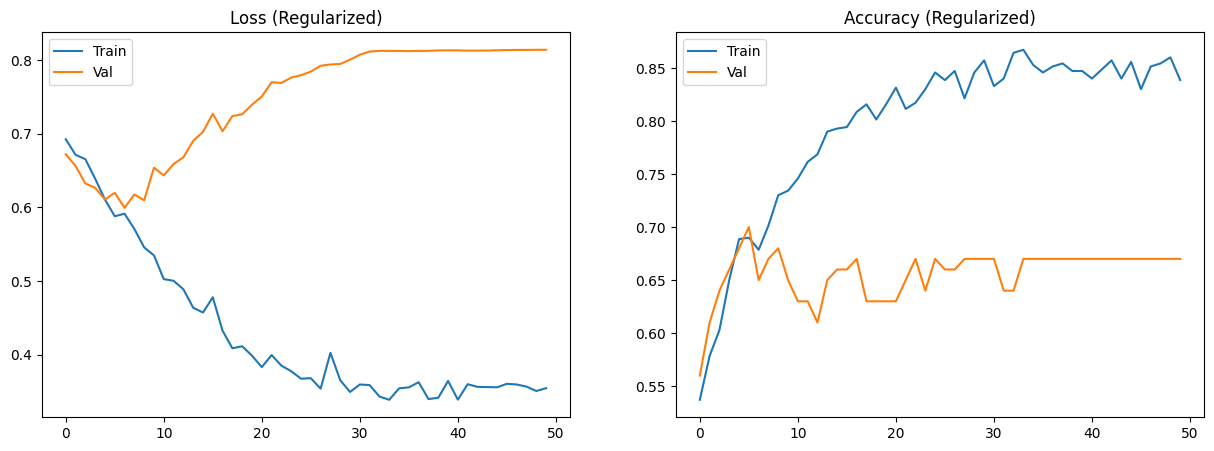

In [78]:
# --- DATA VERIFICATION ---
print(f"--- Data Integrity Check ---")
print(f"Total samples in DataFrame: {len(df)}")
print(f"Total samples in ESM2 embeddings: {len(pooled)}")

# Initialize the dataset
dataset = PeptideMultiModalDataset(
    df=df,
    esm2_embeddings=pooled,
    fit_scaler=True,
    feature_cols=df.columns.tolist()
)

# --- CORRECT 70/20/10 SPLIT ---
train_indices, temp_indices = train_test_split(
    range(len(dataset)), 
    test_size=0.30, 
    random_state=42, 
    stratify=dataset.labels.numpy()
)
# Of the 30% temp, 2/3 (20% total) is Test, 1/3 (10% total) is Val
test_indices, val_indices = train_test_split(
    temp_indices, 
    test_size=1/3, 
    random_state=42, 
    stratify=dataset.labels[temp_indices].numpy()
)

print(f"\n--- Split Sizes ---")
print(f"Train: {len(train_indices)} samples")
print(f"Test:  {len(test_indices)} samples")
print(f"Val:   {len(val_indices)} samples")

# Create Dataloaders
BATCH_SIZE = 128
train_loader = DataLoader(Subset(dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(Subset(dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(Subset(dataset, test_indices), batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Batches in Train Loader: {len(train_loader)}")

# --- MODEL & OPTIMIZER ---
model = BiophysicalFusionClassifier(
    esm2_dim=1280,
    bio_dim=dataset.biophysical.shape[1],
    hidden_dim=128,
    dropout=0.3 # Increased dropout to fight overfitting
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Weight decay (L2 regularization) is key to stop the loss from going to zero too fast
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

# Scheduler: Lower LR if Val Loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=3)

# --- TRAINING LOOP ---
num_epochs = 50
patience = 50
best_val_loss = float('inf')
patience_counter = 0

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(num_epochs):
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    
    for batch in train_loader:
        esm2, bio, labels = batch["esm2"].to(device), batch["biophysical"].to(device), batch["label"].to(device)
        
        logits, _ = model(esm2, bio)
        loss = loss_fn(logits, labels)
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        
        t_loss += loss.item()
        t_correct += (logits.argmax(1) == labels).sum().item()
        t_total += labels.size(0)
    
    train_loss = t_loss / len(train_loader)
    train_acc = t_correct / t_total

    # Validation
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            esm2, bio, labels = batch["esm2"].to(device), batch["biophysical"].to(device), batch["label"].to(device)
            logits, _ = model(esm2, bio)
            loss = loss_fn(logits, labels)
            v_loss += loss.item()
            v_correct += (logits.argmax(1) == labels).sum().item()
            v_total += labels.size(0)
            
    val_loss = v_loss / len(val_loader)
    val_acc = v_correct / v_total
    
    # Step scheduler
    scheduler.step(val_loss)
    
    # Record history
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # torch.save(model.state_dict(), "best_peptide_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"--- Early stopping triggered ---")
            break

# --- FINAL VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss (Regularized)"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_title("Accuracy (Regularized)"); ax2.legend()
plt.show()

Gathering Final Predictions...
Analyzing Feature Utility vs. Model Importance...
✓ Combined feature profile saved to 'feature_diagnostic_profile.csv'


/opt/homebrew/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


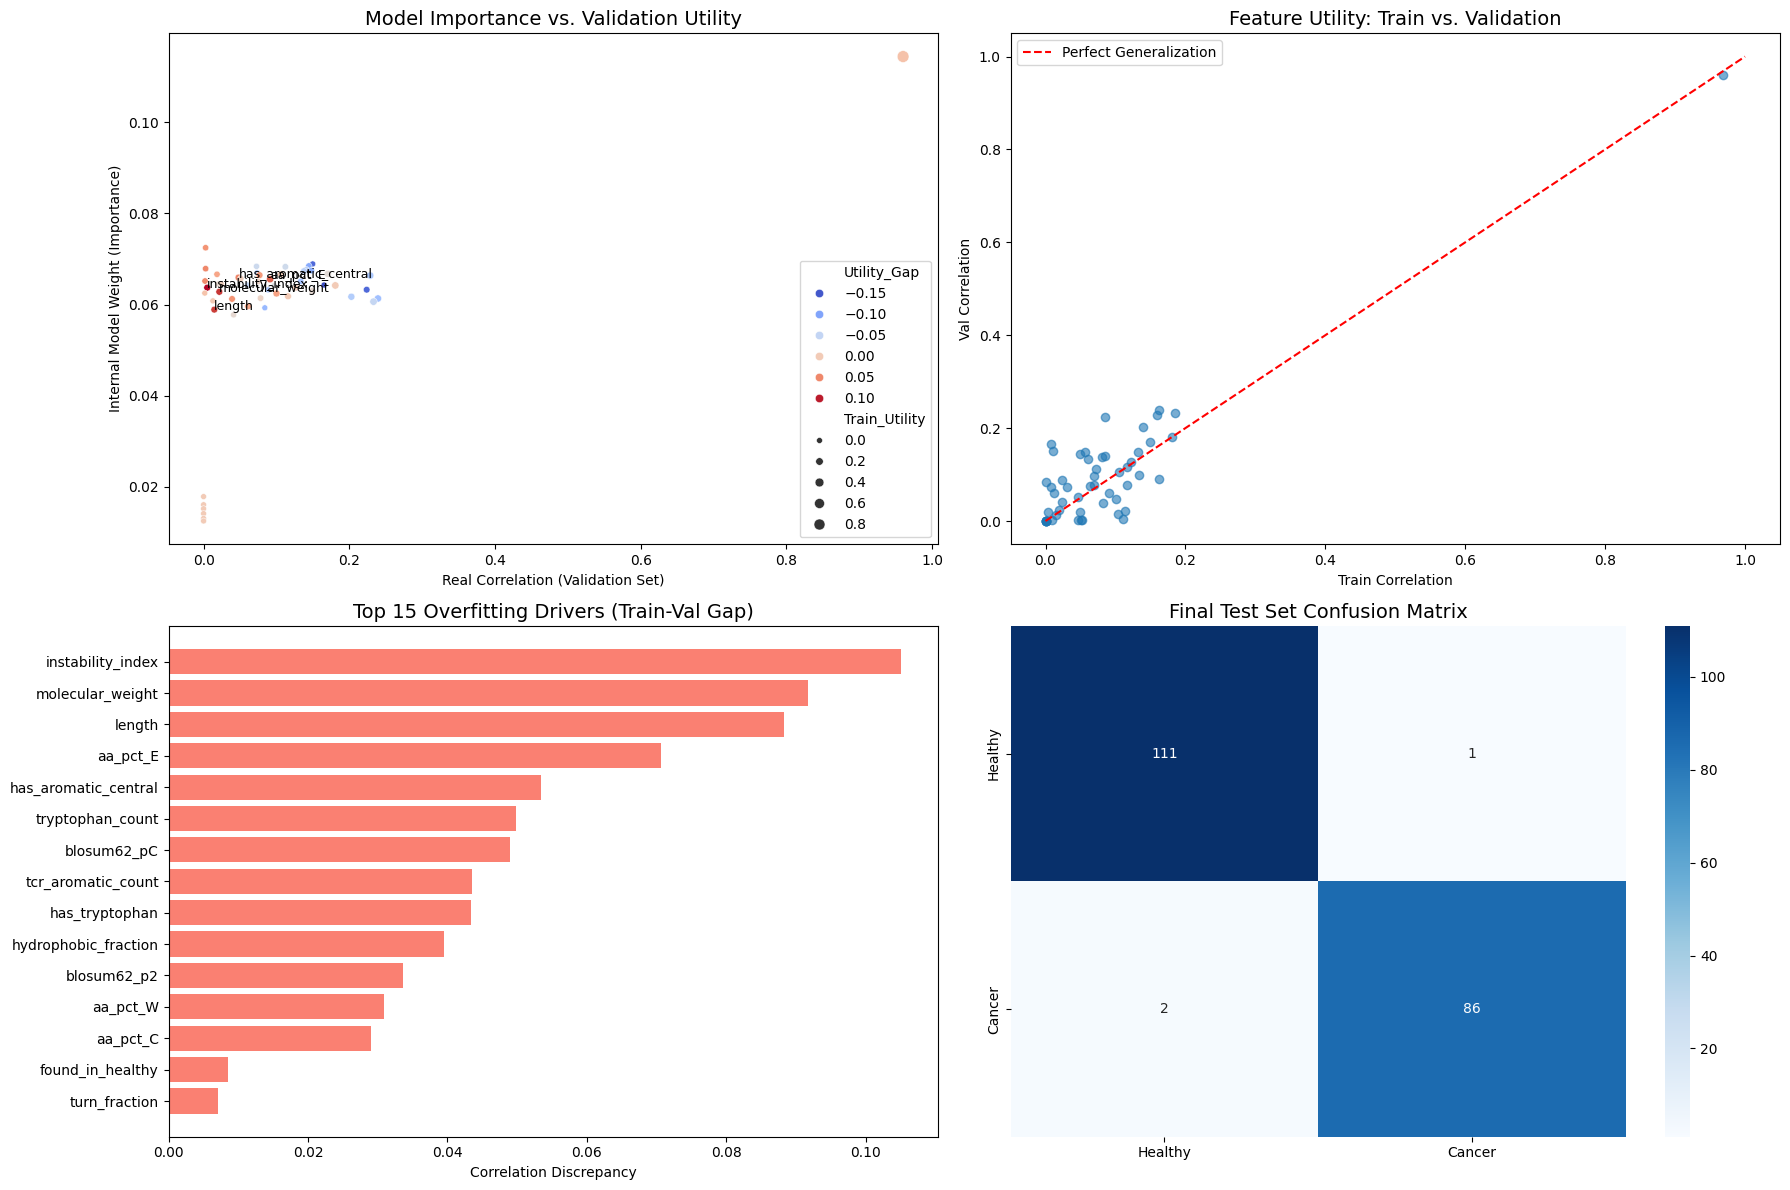

In [ ]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================================
# 1. RUN FINAL TRAINING / EVALUATION
# ==========================================================
model.eval()
all_test_preds, all_test_labels, all_test_probs = [], [], []

print("Gathering Final Predictions...")
with torch.no_grad():
    for batch in test_loader:
        esm2, bio, labels = batch["esm2"].to(device), batch["biophysical"].to(device), batch["label"].to(device)
        logits, _ = model(esm2, bio)
        probs = torch.softmax(logits, dim=1)
        
        all_test_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())
        all_test_probs.extend(probs[:, 1].cpu().numpy())

# Convert to arrays for the diagnostics
test_labels = np.array(all_test_labels)
test_preds = np.array(all_test_preds)
test_probs = np.array(all_test_probs)

# ==========================================================
# 2. GATHER COMBINED FEATURE METRICS
# ==========================================================
print("Analyzing Feature Utility vs. Model Importance...")

# A. Extract Model Importance (Weights)
# We take the mean absolute weight of the first layer in the biophysical branch
bio_weights = model.bio_proj[0].weight.data.abs().mean(dim=0).cpu().numpy()
feature_names = dataset.feature_cols_used

# B. Calculate Correlation Utility (Train vs Val)
def get_correlation_set(indices):
    feat_data = dataset.biophysical[indices].numpy()
    targets = dataset.labels[indices].numpy()
    # Compute Pearson correlation for each feature
    corrs = [np.abs(np.corrcoef(feat_data[:, i], targets)[0, 1]) for i in range(len(feature_names))]
    return np.nan_to_num(corrs)

train_util = get_correlation_set(train_indices)
val_util = get_correlation_set(val_indices)

# C. Create Combined DataFrame
feature_profile = pd.DataFrame({
    'Feature': feature_names,
    'Model_Importance': bio_weights,
    'Train_Utility': train_util,
    'Val_Utility': val_util,
    'Utility_Gap': train_util - val_util
}).sort_values(by='Model_Importance', ascending=False)


# ==========================================================
# 3. VISUALIZATIONS
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Graph A: Model Importance vs Validation Utility (Correlation)
# This shows if the model is prioritizing features that actually work on new data
sns.scatterplot(data=feature_profile, x='Val_Utility', y='Model_Importance', 
                hue='Utility_Gap', palette='coolwarm', size='Train_Utility', ax=axes[0, 0])
axes[0, 0].set_title("Model Importance vs. Validation Utility", fontsize=14)
axes[0, 0].set_xlabel("Real Correlation (Validation Set)")
axes[0, 0].set_ylabel("Internal Model Weight (Importance)")

# Label the top 5 most "suspicious" features (High weight, Low Val Utility)
suspicious = feature_profile.sort_values('Utility_Gap', ascending=False).head(5)
for _, row in suspicious.iterrows():
    axes[0, 0].text(row['Val_Utility'], row['Model_Importance'], row['Feature'], fontsize=9)

# Graph B: Train vs Val Utility Comparison
# Ideally, all features should lie on the diagonal line
axes[0, 1].scatter(feature_profile['Train_Utility'], feature_profile['Val_Utility'], alpha=0.6)
axes[0, 1].plot([0, 1], [0, 1], 'r--', label='Perfect Generalization')
axes[0, 1].set_xlabel("Train Correlation")
axes[0, 1].set_ylabel("Val Correlation")
axes[0, 1].set_title("Feature Utility: Train vs. Validation", fontsize=14)
axes[0, 1].legend()

# Graph C: Top 15 Overfitting Drivers (The Gap)
top_gap = feature_profile.sort_values('Utility_Gap', ascending=False).head(15)
axes[1, 0].barh(top_gap['Feature'], top_gap['Utility_Gap'], color='salmon')
axes[1, 0].set_title("Top 15 Overfitting Drivers (Train-Val Gap)", fontsize=14)
axes[1, 0].set_xlabel("Correlation Discrepancy")
axes[1, 0].invert_yaxis()

# Graph D: Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
axes[1, 1].set_title("Final Test Set Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()